In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# AI Josh Model Evaluation

## Executive Summary

Evaluation of gpt-4.1-mini vs gpt-5-mini showed that:
1. Both models have very high retrieval accuracy
2. Both models have high correctness for positive control questions
3. gpt-5-mini has higher correctness for negative controls on market reports i.e. it is more ready to say "I don't have information about that"

**Main Recommendation**: gpt-5-mini should be used, because it will be available for longer, so service disruptions from model changes will be minimised.

## Method

We compared the performance of gpt-4.1-mini and gpt-5-mini. Our method was:

1. Specify the name of the model of interest in the `.env` file
2. Run `dvc repro` to generate answers to the questions in the truthset, evaluate their correctness, and calculate summary statistics.
3. Compare performance across runs using this notebook

## Results
First, we combine all of the evaluation results together, and remove any ambiguous questions in the truthset. We have the following size of dataset with which to compare model performance:

In [2]:
gpt4 = pd.read_csv("data/gpt4.1-mini/evaluation_results.csv")
gpt5 = pd.read_csv("data/gpt5-mini/evaluation_results.csv")

gpt4['Model'] = 'gpt-4.1-mini'
gpt5['Model'] = 'gpt-5-mini'

# 4. Concatenate the dataframes together
all_data = pd.concat([gpt4, gpt5])
all_data['Question Type'] = all_data['Question Type'].str.strip()
all_data['Document Type'] = all_data['Document Type'].str.strip()

# remove ambiguous questions
all_data = all_data[all_data['Unambiguous']=='Yes'].copy().reset_index(drop=True)

print(f"Total number of model responses: {len(all_data)}")
print(f"Total number of responses from gpt-4.1-mini: {len(all_data[all_data['Model']=='gpt-4.1-mini'])}")
print(f"Total number of responses from gpt-5-mini: {len(all_data[all_data['Model']=='gpt-5-mini'])}")
print(f"Total number of positive controls: {len(all_data[all_data['Question Type'] == 'Positive'])}")
print(f"Total number of negative controls: {len(all_data[all_data['Question Type'] == 'Negative'])}")

Total number of model responses: 268
Total number of responses from gpt-4.1-mini: 134
Total number of responses from gpt-5-mini: 134
Total number of positive controls: 232
Total number of negative controls: 36


### Correctness
Next, we compare the correctness of the models. We see that on all questions combined, the completeness of gpt-4.1-mini is almost identical to gpt-5:

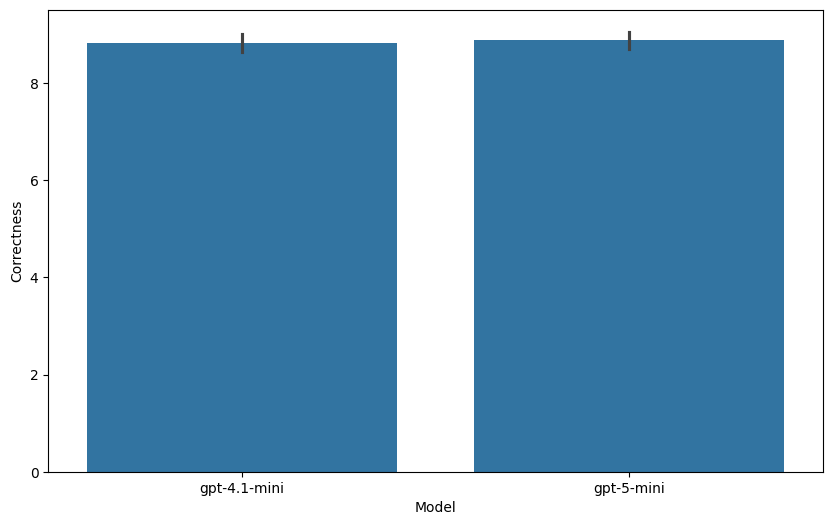

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=all_data, x='Model', y='Correctness', errorbar='se')
# plt.title("Factsheets")
plt.show()
plt.close()

For different doc types, the two model types are broadly similar in their correctness for positive controls. However, there is a large difference in the correctness for negative controls: here, gpt-5-mini outperforms gpt-4.1-mini for Market Reports, despite the two models having identical performance for Fact Sheets. In other words, gpt-5-mini is better at saying when it doesn't have the information to answer a question.

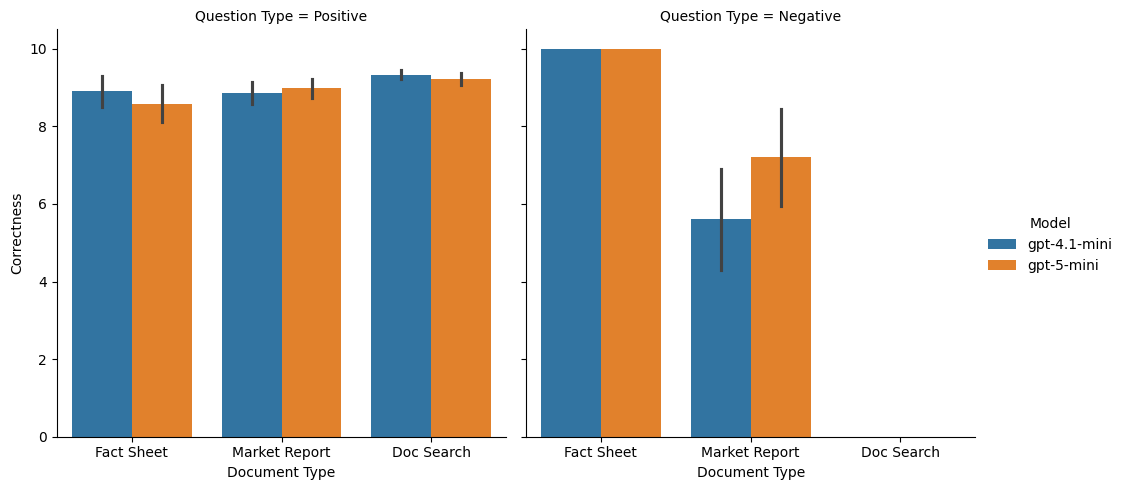

In [6]:
sns.catplot(data=all_data,
            x='Document Type',
            y='Correctness',
            errorbar='se',
            col="Question Type",
            kind='bar',
            hue='Model',
            order=['Fact Sheet', 'Market Report', 'Doc Search'],
            col_order=['Positive', 'Negative'])
plt.show()
plt.close()

### Document Match
Next we look at what percentage of questions have the correct document retrieved, regardless of whether the answer generated was correct or not. This shows that there is no difference in the performance of the models in document retrieval. Both models perform flawlessly on positive control questions about fact sheet and doc search. Performance is still very good on positive control questions about market reports, and negative control questions about fact sheets and market reports, but clearly not as good as positive controls. 

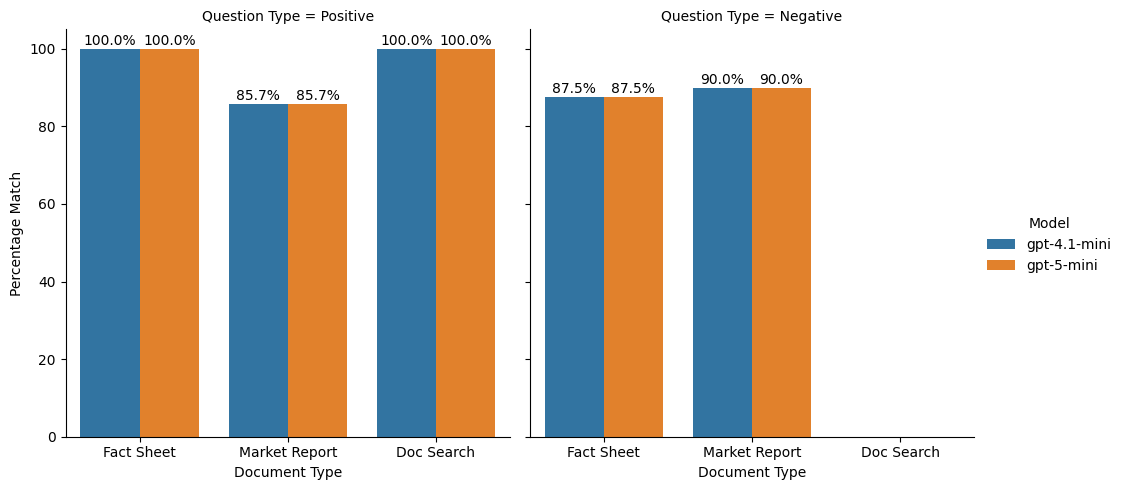

In [5]:
percentage_match = all_data.groupby(['Model', 'Question Type', 'Document Type'])['Document Match'].mean().reset_index()
percentage_match['Document Match'] = round(percentage_match['Document Match'] * 100, 2)
percentage_match.rename(columns={'Document Match': 'Percentage Match'}, inplace=True)

g = sns.catplot(data=percentage_match,
                x='Document Type',
                y='Percentage Match',
                hue='Model',
                col='Question Type',
                kind='bar',
                order=['Fact Sheet', 'Market Report', 'Doc Search'],
                col_order=['Positive', 'Negative'])
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width() / 2., height + 1, f'{height:.1f}%', ha="center")
plt.show()
plt.close()